In [170]:
# AI was used to support code development
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [171]:
full_charging_df = pd.read_feather("../data/full_charging_df.feather")
pd.set_option('display.max_columns', None)
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,inputCount,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,doneDisconnectTimespan,connectionTimespan,doneChargingTimespan,connectionMonth,connectionWeekdayName,connectionYear,isWeekend,connectionHour,disconnectHour,doneChargingHour,loading_duration,connected_duration,ratio_loading_to_connected
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,1,250.0,25.0,100.0,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00,0 days 01:39:40,0 days 06:02:21,0 days 04:22:41,1,Thursday,2020,False,5,11,9.0,262.683333,362.350000,0.724944
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,1,280.0,70.0,250.0,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00,0 days 02:20:16,0 days 09:01:31,0 days 06:41:15,1,Thursday,2020,False,5,14,12.0,401.250000,541.516667,0.740974
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,1,400.0,8.0,20.0,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00,0 days 08:04:16,0 days 10:42:47,0 days 02:38:31,1,Thursday,2020,False,5,16,8.0,158.516667,642.783333,0.246610
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,2,400.0,8.0,20.0,65.0,2020-01-02 06:00:19-08:00,True,2020-01-02 07:04:58-08:00,0 days 01:19:54,0 days 02:38:41,0 days 01:18:47,1,Thursday,2020,False,5,8,7.0,78.783333,158.683333,0.496481
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,1,400.0,16.0,40.0,504.0,2020-01-02 06:00:13-08:00,True,2020-01-02 14:24:01-08:00,0 days 03:51:10,0 days 08:08:39,0 days 04:17:29,1,Thursday,2020,False,6,14,10.0,257.483333,488.650000,0.526928


<h3>Selection of features</h3> 
<p>Since the task is to find clusters for archetypical charging sessions and not for how requests from registered users deviate from the actual charging session, we decided to only incorporate features that are not in the user inputs. Moreover, we calculated two measures from connectionTime, disconnectTime and doneChargingTime. The charging_duration is the timespan between connectionTime and doneChargingTime and the idle_time is the timespan from doneChargingTime to disconnectTime. With this calculation we decreased dimensionality from 4 to only 3 explainable features.</p>

In [172]:
# Calculate timespans
full_charging_df['session_duration'] = (full_charging_df['disconnectTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
full_charging_df['charging_duration'] = (full_charging_df['doneChargingTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
full_charging_df['idle_time'] = (full_charging_df['disconnectTime'] - full_charging_df['doneChargingTime']).dt.total_seconds() / 60

In [173]:
# Correlation between charging duration and kwhDelievered
corr = full_charging_df['charging_duration'].corr(full_charging_df['kWhDelivered'])
print(f"Correlation between charging duration and kWhDelivered: {corr}")

Correlation between charging duration and kWhDelivered: 0.5319936654405529


In [174]:
# Select features for clustering
features = [
    'session_duration',
    'kWhDelivered'
]

In [175]:
# Drop rows with NaN values
X = full_charging_df[features].dropna()
# User_df is the same as full charging df but the columns are dropped where the fetures are nan
user_df = full_charging_df.dropna(subset=features)


# Compare sizes before and after dropping NaNs
print(full_charging_df[features].shape)
print(X.shape)
print(X.head())
print(user_df.shape)

(65037, 2)
(65037, 2)
   session_duration  kWhDelivered
0        362.350000        25.016
1        541.516667        33.097
2        642.783333         6.521
3        158.683333         2.355
4        488.650000        13.375
(65037, 35)


In [176]:
scaler = StandardScaler()
scaler.fit(X)
clustering_scaled = scaler.transform(X)
clustering_scaled_df = pd.DataFrame(clustering_scaled, columns=X.columns, index=X.index)
clustering_scaled_df.head()

,session_duration,kWhDelivered
0,-0.048296,1.292140
1,0.562441,2.078317
2,0.907635,-0.507186
3,-0.742547,-0.912484
4,0.382231,0.159620


In [177]:
k_max = 15
clusters = []
losses = []

for k in range(k_max):
    model = KMeans(n_clusters=k+1, n_init='auto', random_state=42)
    model.fit(clustering_scaled_df)
    clusters.append(k+1)
    losses.append(model.inertia_)

(0.0, 14.0)

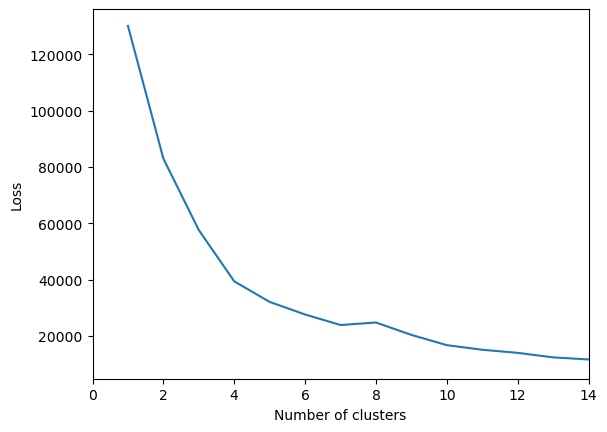

In [178]:
# Plot the loss curve to find the optimal number of clusters
plt.plot(clusters, losses)
plt.ylabel("Loss")
plt.xlabel("Number of clusters")
plt.xlim([0,14])

In [179]:
numbers = ["Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4", "Cluster 5"]


/Applications/anaconda3/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


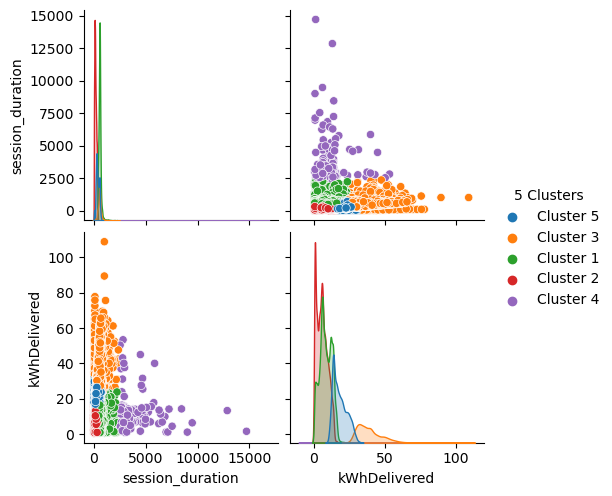

In [180]:
# Test with 5 clusters first

five_means = KMeans(n_clusters=5, n_init='auto', random_state=42)
# Fit algorithm for 5 clusters
five_means.fit(clustering_scaled_df)
X["5 Clusters"] = five_means.predict(clustering_scaled)
X["5 Clusters"] = X["5 Clusters"].apply(lambda x: numbers[x])
sns.pairplot(data=X, hue="5 Clusters")

/Applications/anaconda3/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


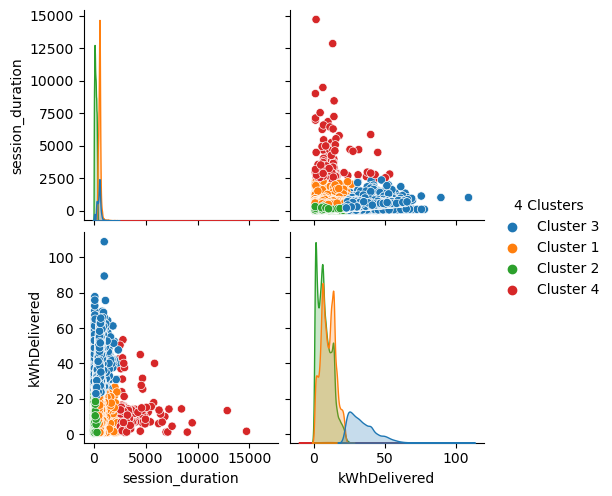

In [215]:
four_means = KMeans(n_clusters=4, n_init='auto', random_state=42)
# Fit algorithm for 4 clusters
four_means.fit(clustering_scaled_df)
X["4 Clusters"] = four_means.predict(clustering_scaled)
X["4 Clusters"] = X["4 Clusters"].apply(lambda x: numbers[x])
sns.pairplot(data=X, hue="4 Clusters")

In [216]:
# Length of each cluster
X["4 Clusters"].value_counts()

Cluster 2    29619
Cluster 1    27030
Cluster 3     8260
Cluster 4      128
Name: 4 Clusters, dtype: int64

In [217]:
# Min, max, median values of clusters
print(X.groupby("4 Clusters")[features].agg(['min', 'max', 'median']))

           session_duration                            kWhDelivered  \
                        min           max       median          min   
4 Clusters                                                            
Cluster 1        297.000000   2308.050000   548.608333        0.506   
Cluster 2          2.066667    402.216667   159.383333        0.501   
Cluster 3          2.550000   2368.700000   513.066667       21.145   
Cluster 4       2331.633333  14716.150000  3581.041667        0.896   

                                 
                   max   median  
4 Clusters                       
Cluster 1    26.513000   9.6305  
Cluster 2    24.830000   6.3610  
Cluster 3   108.797242  31.7545  
Cluster 4    53.282000  11.2745  


In [218]:
# Min, max, median values of the kWhDelivered and session_duration for the whole dataset
print(X[features].agg(['min', 'max', 'median']))

        session_duration  kWhDelivered
min             2.066667      0.501000
max         14716.150000    108.797242
median        369.450000      9.099000


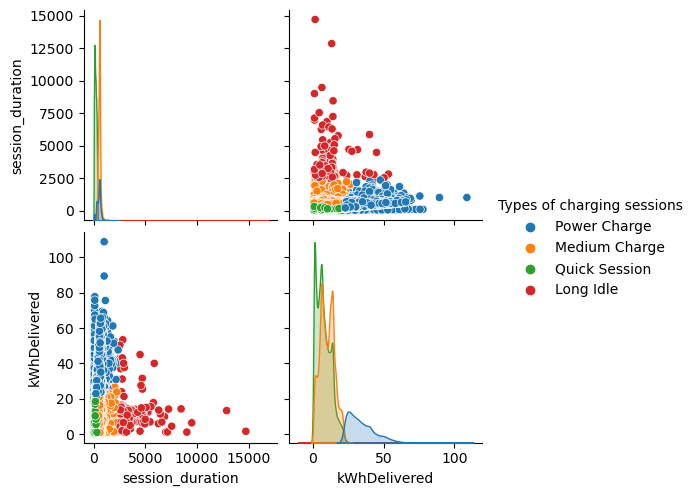

In [219]:
# Rename labels in plot

# New labels
new_numbers = {
    "Cluster 1": "Medium Charge",
    "Cluster 2": "Quick Session",
    "Cluster 3": "Power Charge",
    "Cluster 4": "Long Idle"
}

# Apply the new labels
X["Types of charging sessions"] = X["4 Clusters"].map(new_numbers)

# Plot with the new labels
sns.pairplot(data=X, hue="Types of charging sessions")


<h4>Cluster Description</h4>
<p><b>Cluster 1: Medium Charge </b>-> Charging Events with a medium high session_duration and an average kWh_delivered</p>
<p><b>Cluster 2: Quick Session </b>-> Short charging time with relatively low energy consumption </p>
<p><b>Cluster 3: Power Charge </b>-> Use the highest amount of energy, but are connected within a regular session duration</p>
<p><b>Cluster 4: Long Idle </b>-> Stays connected for a long time, but doesn't charge the whole time</p>

In [236]:
# Append 4 Clusters column on user_df
user_df["4 Clusters"] = X["4 Clusters"]
# Drop rows with userID that occours in general less than 5 times
user_df = user_df[user_df.groupby('userID')['userID'].transform('size') > 5]
# Add a column with the number of sessions per user
user_df["Number of sessions per userID"] = user_df.groupby('userID')['userID'].transform('size')

# Check cluster consistency for each userId
user_cluster_stats = (
    user_df.groupby('userID')['4 Clusters'] # How to best save userId in trained data?
    .value_counts(normalize=True)  # Get proportion of sessions in each cluster
    .reset_index(name='proportion')
)

# Find the most frequent cluster and its proportion for each userId
dominant_clusters = (
    user_cluster_stats.groupby('userID')
    .apply(lambda x: x.loc[x['proportion'].idxmax()])
    .reset_index(drop=True)
)

# Rename for clarity
dominant_clusters = dominant_clusters.rename(
    columns={'cluster': 'dominant_cluster', 'proportion': 'consistency_score'}
)

# Drop all rows where consistency score is below 0.5
dominant_clusters = dominant_clusters[dominant_clusters['consistency_score'] > 0.8]
# I want to have the number of sessions for each user in the dominant_clusters dataframe
dominant_clusters = dominant_clusters.merge(
    user_df['Number of sessions per userID'],
    left_on='userID',
    right_index=True
)

# Merge with user-level data if needed
print(dominant_clusters.head())
print(dominant_clusters.shape)

# Which users are probably long idlers
quick_chargers = dominant_clusters[dominant_clusters['4 Clusters'] == "Cluster 4"]
print(quick_chargers.head())
print(quick_chargers.shape)

   userID 4 Clusters  consistency_score  Number of sessions per userID
1    61.0  Cluster 1           0.837209                            491
3    67.0  Cluster 3           0.803279                            201
6    76.0  Cluster 2           0.965347                            192
7   159.0  Cluster 1           0.914286                            168
9   169.0  Cluster 1           0.827977                             93
(252, 4)
Empty DataFrame
Columns: [userID, 4 Clusters, consistency_score, Number of sessions per userID]
Index: []
(0, 4)
